In [1]:
import cv2
import numpy as np
import json
import matplotlib.pyplot as plt

In [2]:
# Уменьшаем фото для удобной разметки на экране
SCALE = 0.2 # 20% от оригинала, можешь менять

image_orig = cv2.imread("../data/images/parking.jpg")
h, w = image_orig.shape[:2]
image_small = cv2.resize(image_orig, (int(w * SCALE), int(h * SCALE)))

# Хранилище
zones = [] # готовые зоны (каждая = 4 точки)
current_points = [] # точки текущего места (накапливаем клики)

def draw_state(img, zones, current_points):
    """Draws all points and zones in copy of image"""
    canvas = img.copy()
    
    # Готовые зоны — зелёные
    for zone in zones:
        pts = np.array(zone, np.int32)
        cv2.polylines(canvas, [pts], isClosed=True, color=(0, 255, 0), thickness=2)
        # Номер зоны
        cx = int(np.mean([p[0] for p in zone]))
        cy = int(np.mean([p[1] for p in zone]))
        cv2.putText(canvas, str(len(zones)), (cx, cy),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)
    
    # Текущие точки — жёлтые кружки и линии
    for pt in current_points:
        cv2.circle(canvas, pt, 5, (0, 255, 255), -1)
    if len(current_points) > 1:
        for i in range(len(current_points) - 1):
            cv2.line(canvas, current_points[i], current_points[i+1], (0, 255, 255), 1)
    
    return canvas

def mouse_callback(event, x, y, flags, param):
    global current_points, zones
    
    if event == cv2.EVENT_LBUTTONDOWN:
        current_points.append((x, y))
        
        # Как только накопили 4 точки — зона готова
        if len(current_points) == 4:
            zones.append(current_points.copy())
            current_points = []
    
    elif event == cv2.EVENT_RBUTTONDOWN:
        # Правая кнопка — отменить последнюю точку
        if current_points:
            current_points.pop()

In [3]:
# Запускаем окно
cv2.namedWindow("Markup")
cv2.setMouseCallback("Markup", mouse_callback)

print("Guide:")
print("LMB — Point position (need 4 for one place)")
print("RMB — Undo last point")
print("S   — save JSON")
print("Z   — Undo last zone")
print("Q   — Quit")

while True:
    canvas = draw_state(image_small, zones, current_points)
    cv2.imshow("Markup", canvas)
    
    key = cv2.waitKey(1) & 0xFF
    
    if key == ord('q'):
        break
    elif key == ord('z') and zones:
        zones.pop()
    elif key == ord('s'):
        # Масштабируем координаты обратно к оригинальному размеру
        zones_orig = []
        for zone in zones:
            zone_orig = [( int(x / SCALE), int(y / SCALE) ) for x, y in zone]
            zones_orig.append(zone_orig)
        
        data = [{"id": i+1, "points": zone} for i, zone in enumerate(zones_orig)]
        with open("../data/zones/parking_zones.json", "w") as f:
            json.dump(data, f, indent=2)
        print(f"Saved {len(data)} zones in parking_zones.json")

cv2.destroyAllWindows()

Guide:
LMB — Point position (need 4 for one place)
RMB — Undo last point
S   — save JSON
Z   — Undo last zone
Q   — Quit
Saved 16 zones in parking_zones.json


In [5]:
with open("../data/zones/parking_zones.json") as f:
    data = json.load(f)

print(f"Всего зон: {len(data)}")
for zone in data[:5]:
    print(zone)

Всего зон: 16
{'id': 1, 'points': [[445, 360], [1005, 365], [1025, 1295], [450, 1300]]}
{'id': 2, 'points': [[1005, 315], [1580, 280], [1600, 1310], [1020, 1385]]}
{'id': 3, 'points': [[1605, 375], [2220, 365], [2225, 1275], [1600, 1265]]}
{'id': 4, 'points': [[2215, 360], [2785, 355], [2805, 1260], [2230, 1270]]}
{'id': 5, 'points': [[2805, 265], [3395, 290], [3395, 1310], [2840, 1375]]}


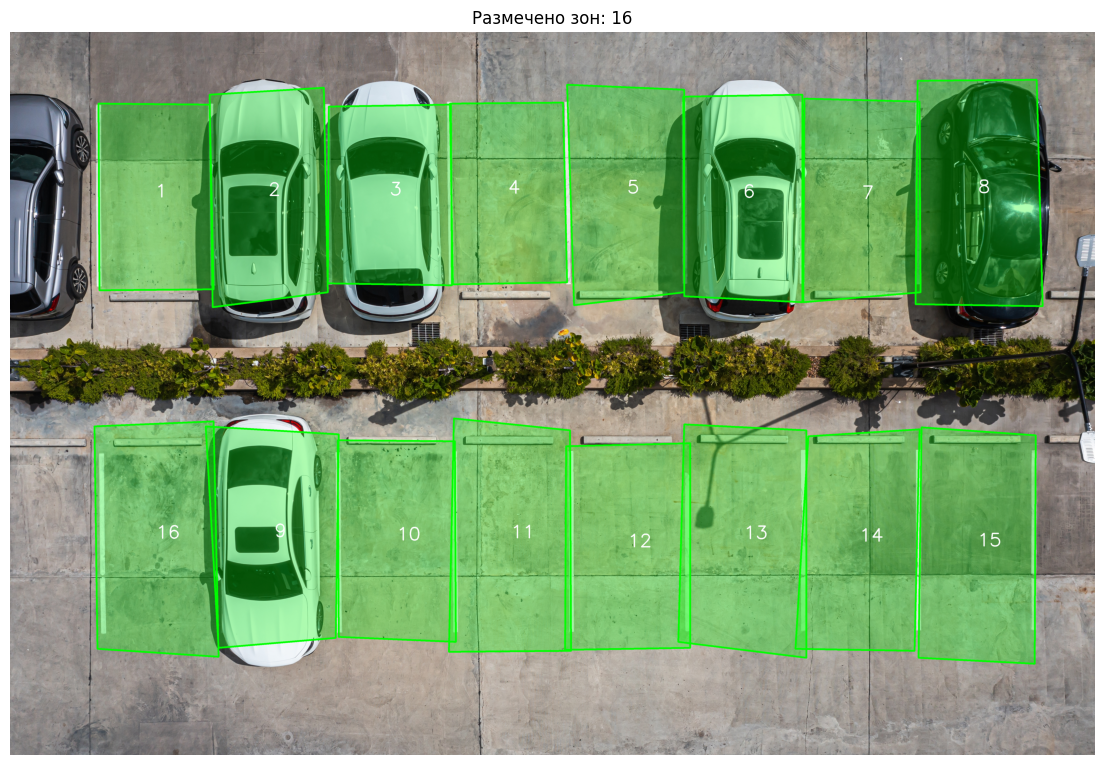

In [6]:
image = cv2.imread("../data/images/parking.jpg")
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

with open("../data/zones/parking_zones.json") as f:
    zones = json.load(f)

# Рисуем зоны
canvas = image_rgb.copy()

for zone in zones:
    pts = np.array(zone["points"], np.int32)
    
    # Заливка полупрозрачная
    overlay = canvas.copy()
    cv2.fillPoly(overlay, [pts], color=(0, 255, 0))
    canvas = cv2.addWeighted(overlay, 0.3, canvas, 0.7, 0)
    
    # Контур
    cv2.polylines(canvas, [pts], isClosed=True, color=(0, 255, 0), thickness=8)
    
    # Номер зоны по центру
    cx = int(np.mean([p[0] for p in zone["points"]]))
    cy = int(np.mean([p[1] for p in zone["points"]]))
    cv2.putText(canvas, str(zone["id"]), (cx, cy),
                cv2.FONT_HERSHEY_SIMPLEX, 3, (255, 255, 255), 6)

plt.figure(figsize=(14, 10))
plt.imshow(canvas)
plt.axis('off')
plt.title(f'Размечено зон: {len(zones)}')
plt.show()